# Challenge: Missing Values

You are challenged to find a compressor that produces the highest compression ratio when compressing the provided satellite observation example dataset with an absolute error bound. The dataset contains missing values. The compressor must preserve the missing values and must not violate the error bound.

This product includes software produced by UChicago Argonne, LLC under Contract No. DE-AC02-06CH11357 with the Department of Energy.

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Challenge Configuration (do not edit)

In [4]:
# Load the data
ds = xr.open_dataset(
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["wvpa"]

In [5]:
eb_abs_check = 1  # kg m-2

## Compressor Configuration (edit here)

In [6]:
eb_abs = 1  # kg m-2

In [7]:
from numcodecs_wasm_zfp import Zfp

codec = Zfp(mode="fixed-accuracy", tolerance=eb_abs, non_finite="allow-unsafe")

## Challenge Evaluation (do not edit)

In [8]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc, out=np.empty(da.shape, dtype=da.dtype)))

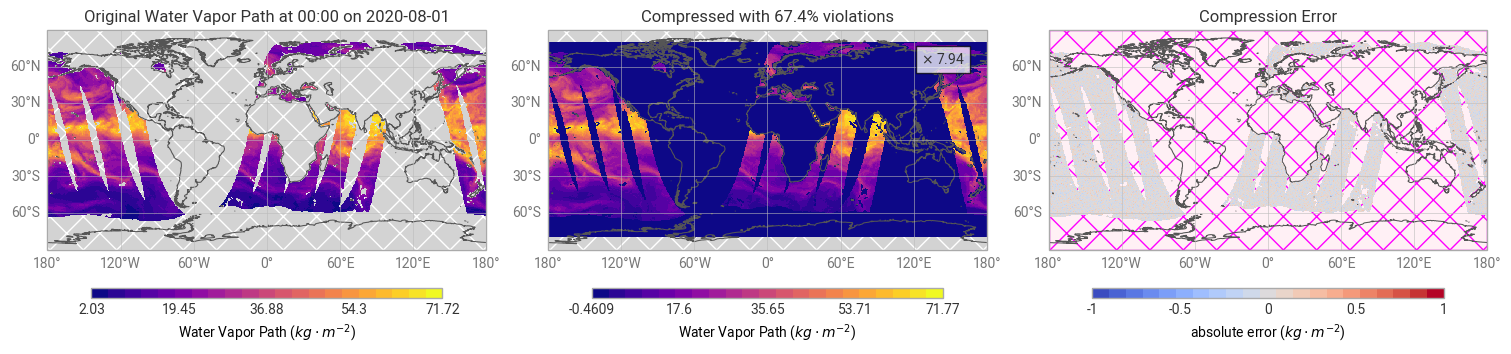

In [9]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

# violation if
# (a) the absolute error bound is exceeded
# (b) missing NaN values are not preserved
violations = np.mean(
    ~((da_dec - da) <= eb_abs_check) | (np.isnan(da_dec) != np.isnan(da))
)
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    xr.where(np.isnan(da) & np.isnan(da_dec), 0, da_dec - da).assign_attrs(
        long_name="absolute error", units=da.units
    ),
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_abs_check, eb_abs_check),
    title="Compression Error",
)

fig.show()